<a href="https://colab.research.google.com/github/varshabantu/Data-Science-Tasks/blob/main/Loan_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Loan Approval Prediction




In [58]:
# import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_diabetes
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score

In [59]:
#Data Preparation
df = pd.read_csv("/content/loan_data.csv")
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


**EDA**

In [60]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [61]:
#Handling outliers in age column
df = df[df["person_age"]<=100]
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,44993.000000,4.499300e+04,44993.000000,44993.000000,44993.000000,44993.000000,44993.000000,44993.000000,44993.000000
mean,27.748428,7.990845e+04,5.394528,9583.176761,11.006448,0.139736,5.866557,632.585713,0.222257
std,5.909737,6.332213e+04,5.927159,6314.802655,2.978985,0.087207,3.877167,50.402411,0.415767
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.719500e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704600e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.577800e+04,8.000000,12237.000000,12.990000,0.190000,8.000000,670.000000,0.000000
max,94.000000,2.448661e+06,76.000000,35000.000000,20.000000,0.660000,30.000000,784.000000,1.000000


,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,44993.000000,4.499300e+04,44993.000000,44993.000000,44993.000000,44993.000000,44993.000000,44993.000000,44993.000000
mean,27.748428,7.990845e+04,5.394528,9583.176761,11.006448,0.139736,5.866557,632.585713,0.222257
std,5.909737,6.332213e+04,5.927159,6314.802655,2.978985,0.087207,3.877167,50.402411,0.415767
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.719500e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704600e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.577800e+04,8.000000,12237.000000,12.990000,0.190000,8.000000,670.000000,0.000000
max,94.000000,2.448661e+06,76.000000,35000.000000,20.000000,0.660000,30.000000,784.000000,1.000000


In [62]:
df.isnull().sum()

,0
person_age,0
person_gender,0
person_education,0
person_income,0
person_emp_exp,0
person_home_ownership,0
loan_amnt,0
loan_intent,0
loan_int_rate,0
loan_percent_income,0


,0
person_age,0
person_gender,0
person_education,0
person_income,0
person_emp_exp,0
person_home_ownership,0
loan_amnt,0
loan_intent,0
loan_int_rate,0
loan_percent_income,0


In [63]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [64]:
df["loan_status"].unique()

array([1, 0])

array([1, 0])

<Axes: xlabel='loan_status', ylabel='Count'>

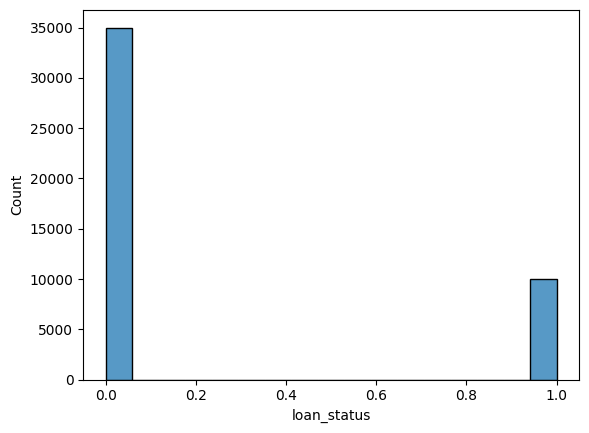

<Axes: xlabel='loan_status', ylabel='Count'>

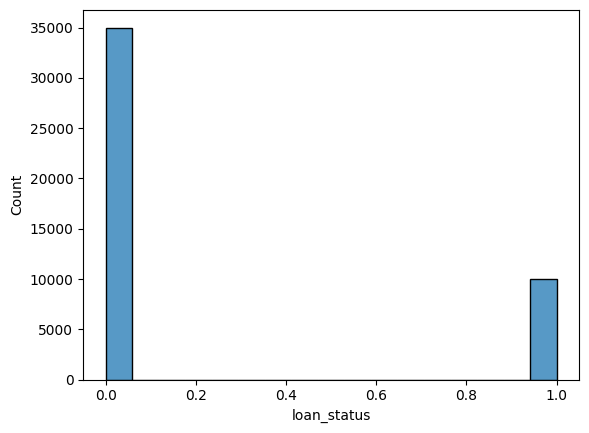

In [65]:
sns.histplot(x="loan_status",data=df)

<Axes: xlabel='person_age', ylabel='Count'>

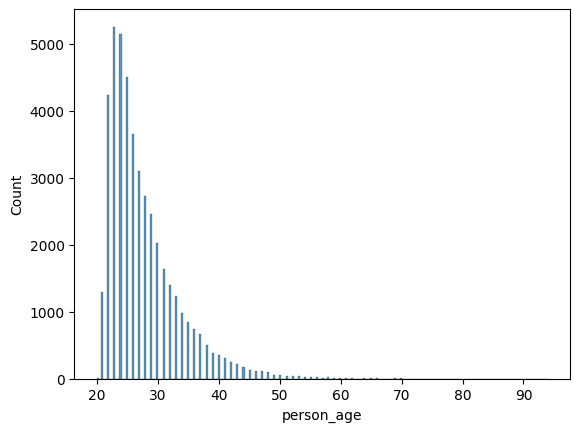

<Axes: xlabel='person_age', ylabel='Count'>

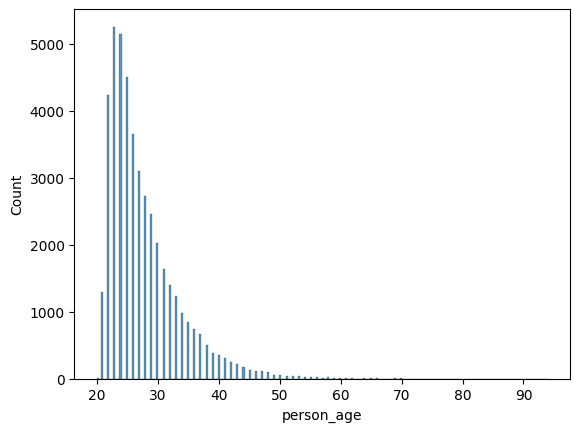

In [66]:
sns.histplot(x="person_age",data=df)

<Axes: xlabel='person_gender', ylabel='count'>

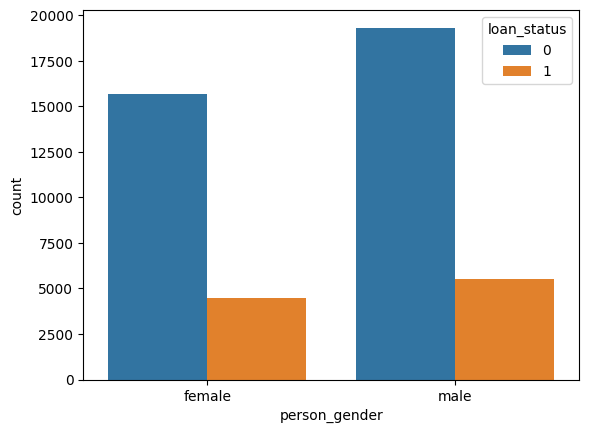

<Axes: xlabel='person_gender', ylabel='count'>

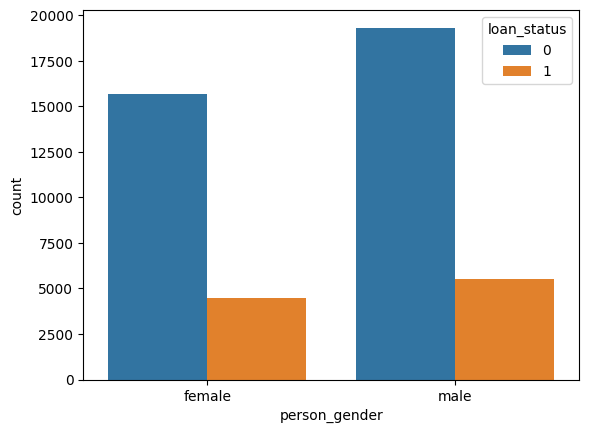

In [67]:
#Check male or female getting more loans
sns.countplot(x="person_gender",hue="loan_status",data=df)

<Axes: xlabel='person_age', ylabel='Count'>

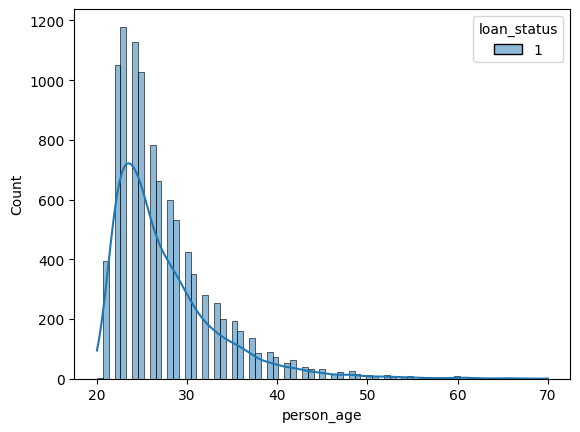

<Axes: xlabel='person_age', ylabel='Count'>

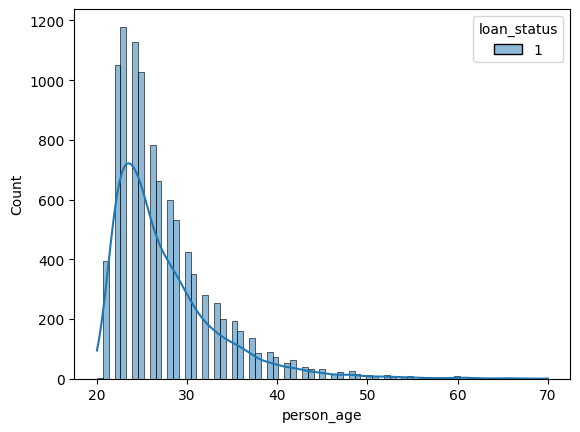

In [68]:
#Which age group is getting more loans
sns.histplot(x="person_age",data=df[df["loan_status"]==1],hue="loan_status",kde=True)

The person age between 20 to 30 getting more loans,The data is positive skew.

<Axes: xlabel='person_education', ylabel='count'>

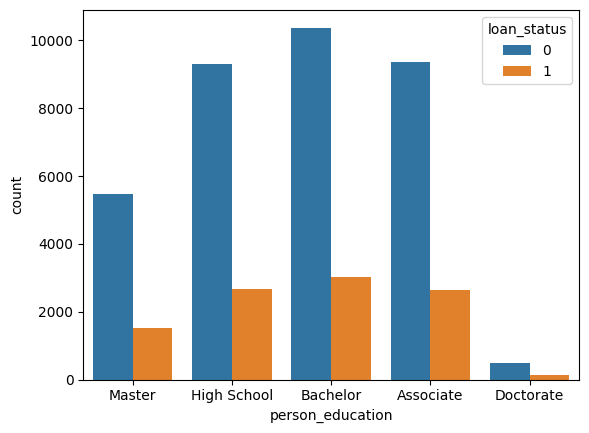

<Axes: xlabel='person_education', ylabel='count'>

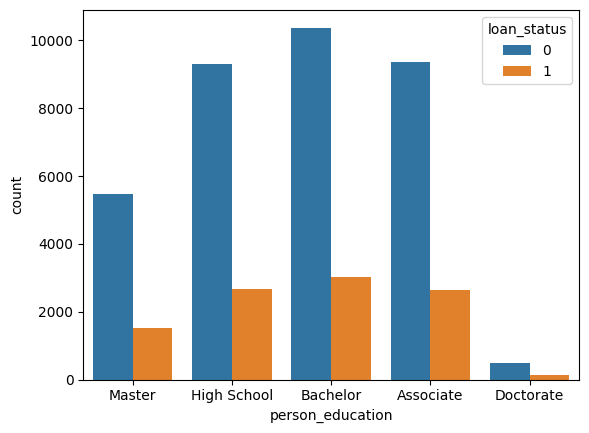

In [69]:
sns.countplot(x="person_education",hue="loan_status",data=df)

In [70]:
#With which average income getting more loans
df.groupby("loan_status")["person_income"].mean()

,person_income
loan_status,
0,85630.263567
1,59886.096900


,person_income
loan_status,
0,85630.263567
1,59886.096900


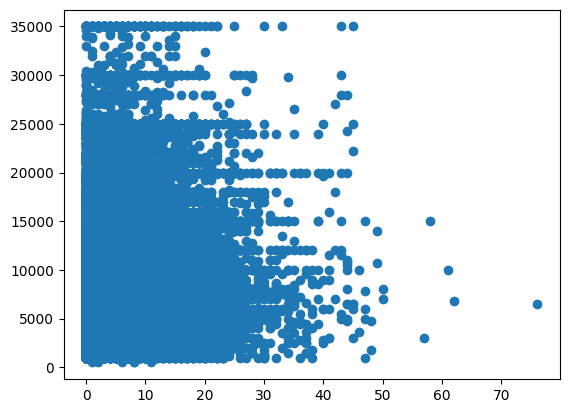

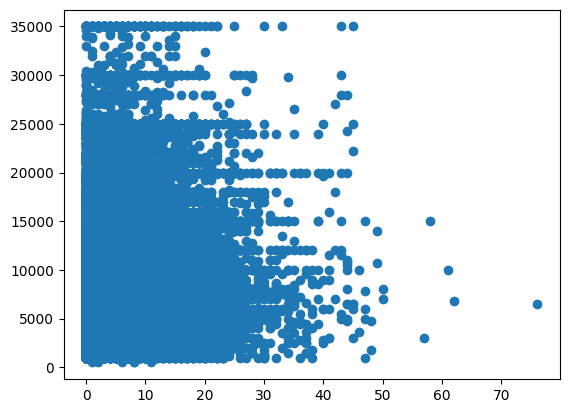

In [71]:
#Person experiences and loan
plt.scatter(df["person_emp_exp"],df["loan_amnt"])

<Axes: xlabel='credit_score', ylabel='Count'>

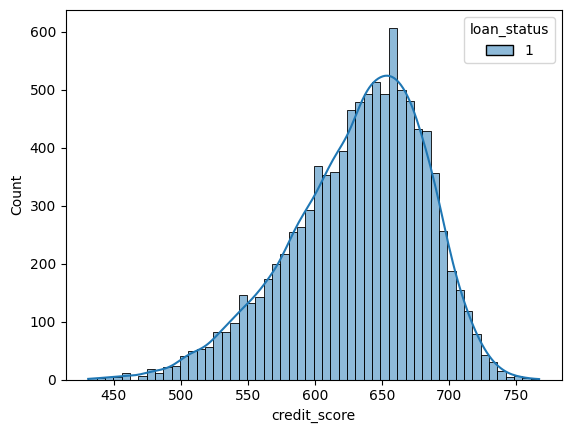

<Axes: xlabel='credit_score', ylabel='Count'>

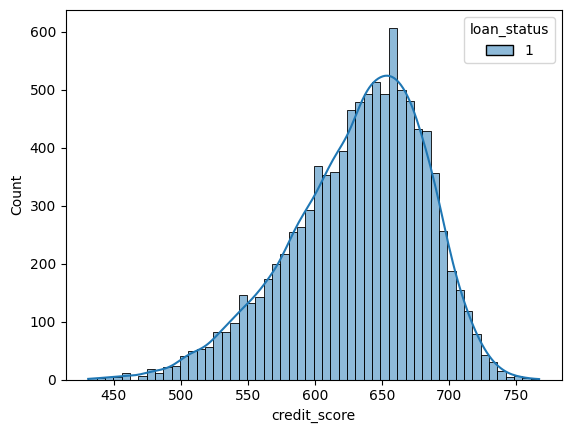

In [72]:
#Distribution of credit score
sns.histplot(x="credit_score",data=df[df["loan_status"]==1],kde=True,hue="loan_status")

<Axes: >

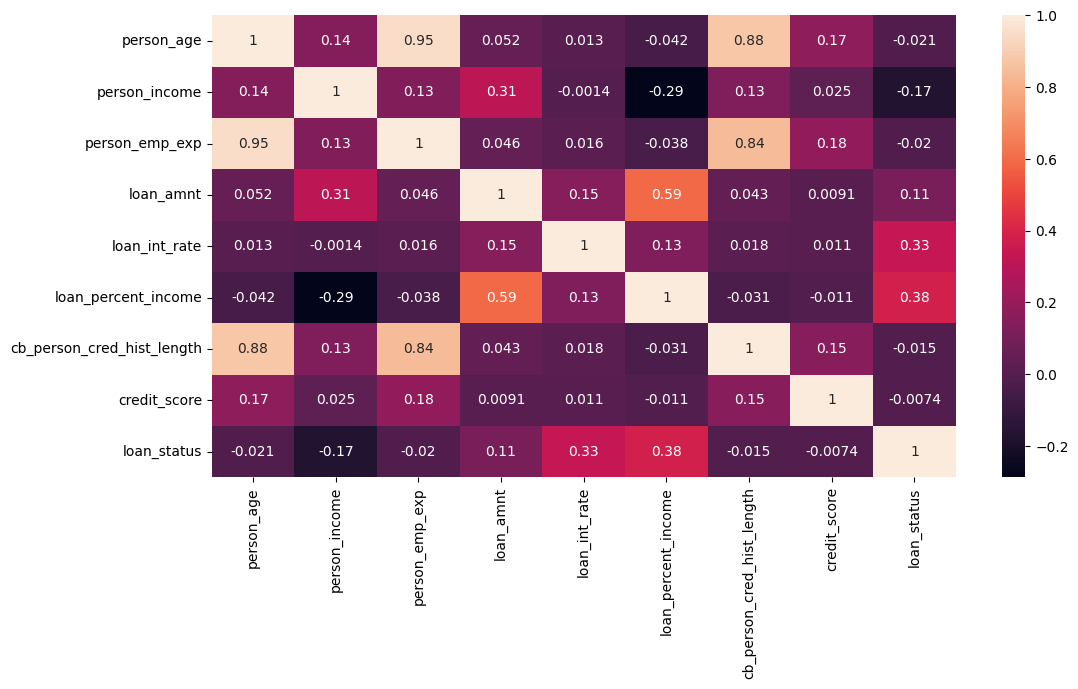

<Axes: >

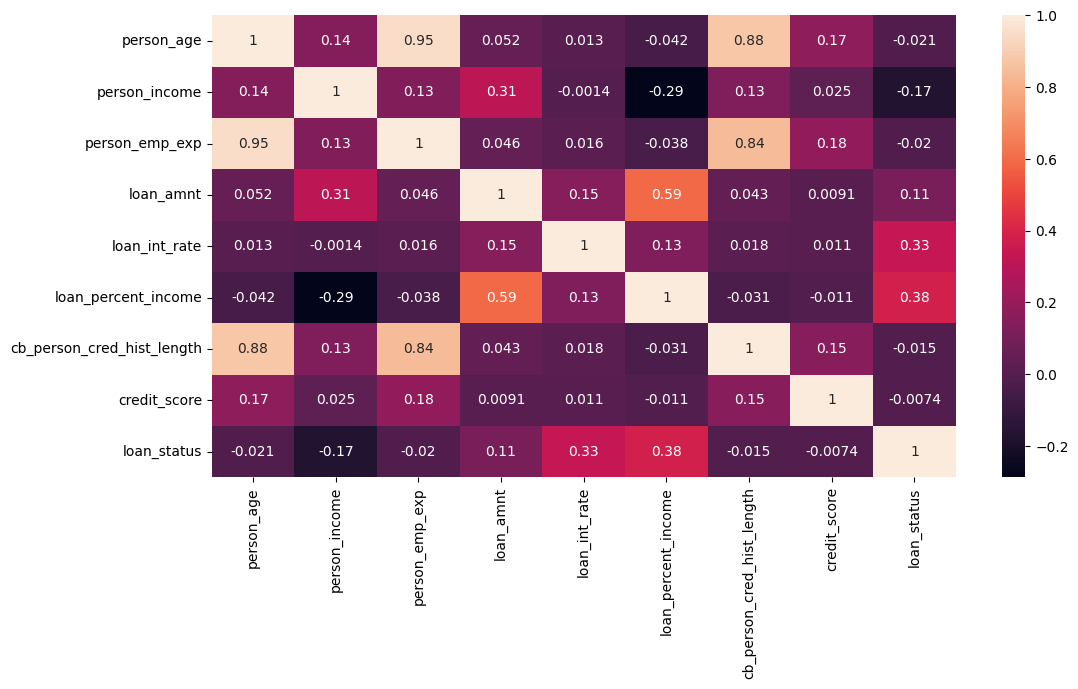

In [73]:
num_cols = [col for col in df.columns if df[col].dtype!=object]
data = df[num_cols].corr()
plt.figure(figsize=(12,6))
sns.heatmap(data,annot=True)

**Model Training**

In [55]:
#Encoding
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
for col in df.columns:
    if df[col].dtype == object:
        df[col] = encoder.fit_transform(df[col])

In [56]:
#Divide the data into input and output
X = df.drop("loan_status",axis=1)
y = df.loan_status

In [57]:
#Splitting the data for training and testing
Xtrain,Xtest,ytrain,ytest = train_test_split(X,y,test_size=0.3,random_state=42)

In [74]:
#Scaling process
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
Xtrain = scaler.fit_transform(Xtrain)
Xtest = scaler.transform(Xtest)

In [48]:
model = SVC()
model.fit(Xtrain,ytrain)


SVC(kernel='linear')

SVC(kernel='linear')

**Model Evaluation and Tuning**

In [75]:
ypred = model.predict(Xtest)
ypred

array([1, 0, 0, ..., 1, 0, 1])

array([1, 0, 0, ..., 1, 0, 1])

array([1, 0, 0, ..., 1, 0, 1])

In [76]:
confusion_matrix(ytest,ypred)

array([[9876,  614],
       [ 821, 2187]])

array([[9876,  614],
       [ 821, 2187]])

array([[9876,  614],
       [ 821, 2187]])

In [77]:
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.92      0.94      0.93     10490
           1       0.78      0.73      0.75      3008

    accuracy                           0.89     13498
   macro avg       0.85      0.83      0.84     13498
weighted avg       0.89      0.89      0.89     13498

              precision    recall  f1-score   support

           0       0.92      0.94      0.93     10490
           1       0.78      0.73      0.75      3008

    accuracy                           0.89     13498
   macro avg       0.85      0.83      0.84     13498
weighted avg       0.89      0.89      0.89     13498

              precision    recall  f1-score   support

           0       0.92      0.94      0.93     10490
           1       0.78      0.73      0.75      3008

    accuracy                           0.89     13498
   macro avg       0.85      0.83      0.84     13498
weighted avg       0.89      0.89      0.89     13498



In [78]:
print("Training Eff: ",model.score(Xtrain,ytrain))
print("Testing Eff: ",model.score(Xtest,ytest))

Training Eff:  0.89118907763137
Testing Eff:  0.893687953770929
Training Eff:  0.89118907763137
Testing Eff:  0.893687953770929
Training Eff:  0.89118907763137
Testing Eff:  0.893687953770929


In [79]:
new_data = df.iloc[0:1,:-1]
new_data = scaler.transform(new_data)
pred = model.predict(new_data)[0]
if pred == 0:
    print("The loan is not Approved")
else:
    print("Loan is Approved")
df

Loan is Approved


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,0,4,71948.0,0,3,35000.0,4,16.02,0.49,3.0,561,0,1
1,21.0,0,3,12282.0,0,2,1000.0,1,11.14,0.08,2.0,504,1,0
2,25.0,0,3,12438.0,3,0,5500.0,3,12.87,0.44,3.0,635,0,1
3,23.0,0,1,79753.0,0,3,35000.0,3,15.23,0.44,2.0,675,0,1
4,24.0,1,4,66135.0,1,3,35000.0,3,14.27,0.53,4.0,586,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,1,0,47971.0,6,3,15000.0,3,15.66,0.31,3.0,645,0,1
44996,37.0,0,0,65800.0,17,3,9000.0,2,14.07,0.14,11.0,621,0,1
44997,33.0,1,0,56942.0,7,3,2771.0,0,10.02,0.05,10.0,668,0,1
44998,29.0,1,1,33164.0,4,3,12000.0,1,13.23,0.36,6.0,604,0,1


Loan is Approved


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,0,4,71948.0,0,3,35000.0,4,16.02,0.49,3.0,561,0,1
1,21.0,0,3,12282.0,0,2,1000.0,1,11.14,0.08,2.0,504,1,0
2,25.0,0,3,12438.0,3,0,5500.0,3,12.87,0.44,3.0,635,0,1
3,23.0,0,1,79753.0,0,3,35000.0,3,15.23,0.44,2.0,675,0,1
4,24.0,1,4,66135.0,1,3,35000.0,3,14.27,0.53,4.0,586,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,1,0,47971.0,6,3,15000.0,3,15.66,0.31,3.0,645,0,1
44996,37.0,0,0,65800.0,17,3,9000.0,2,14.07,0.14,11.0,621,0,1
44997,33.0,1,0,56942.0,7,3,2771.0,0,10.02,0.05,10.0,668,0,1
44998,29.0,1,1,33164.0,4,3,12000.0,1,13.23,0.36,6.0,604,0,1


ValueError: could not convert string to float: 'female'

In [ ]:
new_data

array([[-0.9748407 , -1.10609134,  1.52338536, -0.12628515, -0.91083549,
         0.90277354,  4.05432565,  0.85669212,  1.6916633 ,  4.02316232,
        -0.74050138, -1.42293835, -1.01172133]])

array([[-0.9748407 , -1.10609134,  1.52338536, -0.12628515, -0.91083549,
         0.90277354,  4.05432565,  0.85669212,  1.6916633 ,  4.02316232,
        -0.74050138, -1.42293835, -1.01172133]])